In [1]:
from IPython.display import HTML, Javascript, display

display(HTML("""
<style>
a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* markdown tabela – zadrži staro ponašanje */
table:not(.dataframe) tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* dataframe – samo pravo zaglavlje */
table.dataframe thead tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* index kolona dataframe da ne bude bold */
table.dataframe tbody th {
    font-weight: normal !important;
}

/* linija ispod poslednjeg reda */
tbody tr:last-child td,
tbody tr:last-child th {
    border-bottom: 1px solid #aaa !important;
}

/* caption */
caption,
.table-caption,
p.caption,
div.caption,
figcaption {
    text-align: center !important;
    font-weight: bold !important;
}
</style>
"""))

display(Javascript("""
function promeniTableUTabela() {
    const selectors = [
        "caption",
        ".table-caption",
        "p.caption",
        "div.caption",
        "figcaption",
        ".caption-number"
    ];

    document.querySelectorAll(selectors.join(",")).forEach(function(el) {
        if (el.innerHTML.includes("Table")) {
            el.innerHTML = el.innerHTML.replace(/\\bTable\\b/g, "Tabela");
        }
    });
}

promeniTableUTabela();

/* ako se notebook kasnije rerenderuje */
const observer = new MutationObserver(function() {
    promeniTableUTabela();
});

observer.observe(document.body, {
    childList: true,
    subtree: true
});
"""))

<IPython.core.display.Javascript object>

# Algoritam k-najbližih suseda

:::{admonition} Ciljevi
:class: note

- Upoznati osnovni princip rada algoritma **k-najbližih suseda (k-NN)**.
- Objasniti koncept **sličnosti** i značaj **mere rastojanja** u procesu klasifikacije i regresije.
- Predstaviti uticaj parametra **k** na performanse modela.
- Analizirati prednosti i ograničenja algoritma.
- Prikazati primenu algoritma u **klasifikacionim** i **regresionim** zadacima.
- Upoznati postupak implementacije algoritma korišćenjem biblioteke **scikit-learn**.
- Razumeti značaj **normalizacije podataka** u radu algoritma k-NN.

:::


:::{admonition} Ishodi učenja
:class: note

Po završetku ove nastavne jedinice student će biti sposoban da:

- Objasni princip rada algoritma **k-najbližih suseda**.
- Definiše i primeni različite **mere rastojanja** (npr. Euklidsko rastojanje) u zavisnosti od problema.
- Izabere odgovarajuću vrednost parametra **k** i obrazloži njen uticaj na model.
- Primeni algoritam k-NN na konkretnom skupu podataka za **klasifikaciju** ili **regresiju**.
- Izvrši evaluaciju modela korišćenjem odgovarajućih **metrika evaluacije**.
- Prepozna situacije u kojima je algoritam k-NN pogodan, kao i njegove potencijalne nedostatke (osetljivost na **dimenzionalnost** i **skaliranje podataka**).
- Implementira k-NN model u programskom jeziku **Python** koristeći biblioteku **scikit-learn**.
:::


## Uvod

Algoritam $k$-najbližih suseda (engl. $k$-nearest neighbors, KNN) predstavlja jedan od najjednostavnijih i najčešće korišćenih metoda nadgledanog učenja. Osnovni princip KNN algoritma klasifikacije zasniva se na određivanju pripadnosti posmatrane instance na osnovu njegove prostorne bliskosti sa već poznatim primerima, zapravo algoritam pronalazi $k$ najbližih primera iz skupa za učenje, koji su mu najbliži u smislu izabrane metrike, i posmatranoj instanci pridružuje klasu koja se najčešće javlja medu tih $k$ najbližih suseda. 

Osnovna pretpostavka ovog pristupa je da tačke koje su prostorno bliske ujedno pripadaju istoj ili sličnoj grupi. Pored klasifikacije, ovaj metod se uspešno primenjuje i u regresionim zadacima.  U slučaju regresije, algoritam posmatra numeričke vrednosti izlazne promenljive kod $k$ najbližih instanci i predviđena vrednost ciljnog atributa izračunava kao aritmetičku sredinu najbližih instanci. Ovaj algoritam pripada grupi modela zasnovanih na instancama (engl. Instance-based), jer ne gradi eksplicitnu matematičku formulu ili skup pravila iz podataka, već pamti primere iz skupa za trening i na osnovu njih donosi odluke o klasifikaciji novih primera.

> Najjednostavnije rečeno, KNN funkcioniše po principu „reci mi s kim se družiš, pa ću ti reći ko si“ ili „reci mi ko su ti najbliži susedi, pa ću ti reći kojoj klasi pripadaš“, jer odluku donosi na osnovu osobina i oznaka najbližih podataka u prostoru obeležja.
> 
---

Ovaj algoritam se definiše kao neparametarski, što znači da ne pravi pretpostavke o raspodeli podataka. Broj
suseda $k$ predstavlja ključni hiperparametar modela. Za razliku od običnih parametara koje algoritam
samostalno izračunava tokom procesa obuke, hiperparametre mi zadajemo pre početka učenja. Pravilnim
podešavanjem vrednosti $k$ postiže se optimalan balans između tačnosti na poznatim podacima i sposobnosti
uopštavanja (generalizacije) na nove, neviđene primere.

#### Primer iz prakse: Optimizacija logističkih resursa pomoću KNN algoritma

U jednoj logističkoj kompaniji svakodnevno je potrebno odrediti optimalan broj vozila koja se šalju u različite delove grada, kako bi se minimizovali troškovi uz istovremeno ispunjenje svih zahteva kupaca. Odluke se donose na osnovu istorijskih podataka koji sadrže informacije o prethodnim radnim danima. Svaki pojedinačni dan prikazan je u formi vektora karakteristika koji sadrži sledeće atribute: dan u nedelji, vremenske uslove (kiša, sneg ili sunčano), ukupan broj primljenih porudžbina i saobraćajne parametre (poput nivoa zagušenja), dok je ciljna promenljiva optimalan broj angažovanih vozila zabeležen tog specifičnog dana. Na osnovu ovih vektora, algoritam meri sličnost nove situacije sa podacima iz prošlosti. Svaka karakteristika (poput vremena ili gužve) posmatra se kao jedna koordinata, pa se podaci prikazuju kao tačke u prostoru i izračunava se njihova udaljenost. Kada se u sistem unese novi radni dan (npr. kišni utorak sa velikim brojem porudžbina i saobraćajnim gužvama), algoritam k-najbližih suseda automatski generiše predviđanje kroz sledeće tri ključne faze:


1. **Pronalaženje najsličnijih primera (identifikacija suseda)** Algoritam analizira bazu podataka kako bi identifikovao $k$ istorijskih dana čije karakteristike (vreme, gužva, broj porudžbina) matematički najviše odgovaraju trenutnim uslovima.

2. **Analiza odabranih suseda** Sistem pristupa podacima o broju vozila koja su bila angažovana tokom tih $k$ identifikovanih, najsličnijih dana iz prošlosti.

3. **Izračunavanje konačnog ishoda (predviđanje)** Na osnovu vrednosti dobijenih od suseda, algoritam generiše finalnu procenu. To se postiže izračunavanjem **aritmetičke sredine** (kod regresije, za dobijanje tačnog broja vozila) ili određivanjem **najučestalije kategorije** (kod klasifikacije).

:::{admonition} Ključni aspekti konfiguracije KNN algoritma
:class: note

- Izbor metrike udaljenosti: Na koji način ćemo kvantifikovati sličnost između instanci? Izbor metrike (npr. Euklidska, Menhetn ili Minkovski udaljenost) zavisi od prirode podataka.
- Strategija agregacije: Kod klasifikacije se najčešće koristi glasanje većine (engl. majority voting), dok se kod regresije izračunava aritmetička sredina njihovih vrednosti.
- Ponderisanje značaja instanci: Da li sve instance treba da imaju podjednak uticaj na konačnu odluku? U naprednijim pristupima, veći uticaj u donošenju odluke imaju instance koje su prostorno bliže posmatranoj tački, dok one udaljenije instance imaju manji značaj u procesu odlučivanja.
- Optimizacija parametra $k$: Koliki je optimalan broj suseda koje treba razmatrati? Pronalaženje prave vrednosti parametra $k$ ključno je za postizanje balansa između stabilnosti modela i njegove osetljivosti na bitne lokalne promene u podacima.


:::

#### Metrike udaljenosti 
Da bi algoritam identifikovao susede, neophodno je precizno izmeriti prostorno rastojanje između novog podatka i ostatka skupa podataka. U zavisnosti od prirode problemai tipa podataka, primenjuju se različite matematičke metrike udaljenosti:
- Euklidska udaljenost (engl. Euclidean distance) je najčešće korišćena mera, i meri najkraće (pravolinijsko) rastojanje između dve tačke u prostoru. Naziv je dobila po starogrčkom matematičaru Euklidu, koji se smatra utemeljivačem geometrije. Primena ove metrike najefikasnija je na numeričkim podacima, neophodno je osigurati da su podaci pravilno skalirani, jer bi u suprotnom promenljive sa većim brojčanim rasponima neopravdano dominirale u izračunavanju udaljenosti. Euklidska udaljenost za dve tačke $P = (p_1, p_2, \dots, p_n)$ i $Q = (q_1, q_2, \dots, q_n)$ u $n$-dimenzionalnom prostoru, se određuje kao koren sume kvadrata razlika njihovih koordinata:

$$d(P, Q) = \sqrt{(p_1 - q_1)^2+(p_2 - q_2)^2+\cdots+(p_n - q_n)^2}.$$

- Čebiševljeva udaljenost (engl. Chebyshev distance) se definiše se kao rastojanje između dve tačke i određuje se kao najveća apsolutna razlika njihovih odgovarajućih koordinata. Metrika je nazvana po ruskom matematičaru Pafnutiju Čebiševu. Ova metrika se često primenjuje u logistici i robotskom planiranju putanja, jer vreme potrebno za kretanje od tačke A do tačke B zavisi od dimenzije u kojoj je potrebno uložiti najviše vremena za savladavanje rastojanja. Čebiševljeva udaljenost za dve tačke $P = (p_1, p_2, \dots, p_n)$ i $Q = (q_1, q_2, \dots, q_n)$ u $n$-dimenzionalnom prostoru, rastojanje se izračunava pomoću $L_\infty$ norme:

$$d(P, Q) = \max_{i} (|p_i - q_i|).$$
- Menhetn udaljenost (engl. Manhattan distance ili City block distance) meri rastojanje između dve tačke tako što sabira apsolutne vrednosti razlika njihovih odgovarajućih koordinata. Ova mera predstavlja dužinu putanje koja je ograničena isključivo na horizontalne i vertikalne korake, bez dijagonalnog kretanja, zbog čega se često naziva i 'city block' razdaljina. Menhetn udaljenost za dve tačke $P = (p_1, p_2, \dots, p_n)$ i $Q = (q_1, q_2, \dots, q_n)$ u $n$-dimenzionalnom prostoru, predstavlja sumu apsolutnih razlika njihovih odgovarajućih koordinata:

$$d(P, Q) = \sum_{i=1}^{n} |p_i - q_i|.$$


Iako postoje različite mere sličnosti, Euklidsko rastojanje predstavlja podrazumevani izbor (engl. default), jer se u praksi pokazalo da ova metrika nudi optimalan balans između jednostavnosti i tačnosti kod većine uobičajenih skupova podataka.

*Realni primeri i interpretacija mera rastojanja*

Izbor metrike rastojanja direktno utiče na način na koji KNN algoritam definiše sličnost između podataka. U nastavku su prikazani intuitivni primeri tri najčešće korišćene mere distance.

1. **Euklidska udaljenost – „vazdušna linija“**

*Primer:* Zamislimo let drona između dve tačke u gradu.  
- Lokacija A: 2 km istočno, 3 km severno  
- Lokacija B: 5 km istočno, 7 km severno.

Dron se kreće pravolinijski, najkraćom mogućom putanjom, bez ograničenja putnom mrežom. Ovo rastojanje predstavlja **Euklidsku udaljenost**, odnosno direktnu geometrijsku distancu između dve tačke u prostoru:

$$
d = \sqrt{(5 - 2)^2 + (7 - 3)^2} = 5.
$$

Dakle, direktno rastojanje između lokacija A i B iznosi 5 kilometara.

👉 *Primena:* Koristi se kada želimo da merimo najkraće rastojanje u kontinualnom prostoru, na primer u obradi slika, prepoznavanju lica ili analizi fizičkih koordinata.

---

2. **Menhetn udaljenost – kretanje po mreži (L1 norma)**

*Primer:* Posmatrajmo kretanje taksi vozila kroz grad sa ortogonalno raspoređenim ulicama. Vozilo ne može da se kreće dijagonalno, već se pomera duž osa. Pretpostavimo da je početna tačka $A(0,0)$, ako je kretanje na primer prvo 3 km ka istoku, pa 4 km ka severu, onda je krajnja tačka $B(3,4)$, tada: 

$$
d = |3 - 0| + |4 - 0| = 7.
$$

Dakle, ukupna Menhetn udaljenost iznosi 7 kilometara, jer se kretanje odvija duž osa (horizontalno i vertikalno), bez dijagonalnog puta.
Menhetn udaljenost predstavlja zbir apsolutnih razlika po svakoj koordinati i poznata je i kao „taxicab“ geometrija.

👉 *Primena:* Često se koristi u logistici, planiranju ruta i u situacijama gde su atributi međusobno nezavisni i gde promena po jednoj osi ne utiče na drugu.

---

3. **Minkovski udaljenost – opšti matematički okvir**

*Primer:* Pretpostavimo da želimo da izmerimo sličnost između dva klijenta banke na osnovu sledećih karakteristika: godine starosti, godišnji prihod (u hiljadama €), broj kupovina karticom mesečno. Posmatramo dva klijenta banke pri čemu Klijent A ima 30 godina, godišnji prihod od 50 hiljada evra i u proseku 20 kupovina mesečno, dok Klijent B ima 40 godina, godišnji prihod od 80 hiljada evra i obavlja oko 10 kupovina mesečno. Podatke o klijentima zapisujemo u obliku vektora: $A = (30, 50, 20)$  i $B = (40, 80, 10)$. Računanje Minkovskijeve udaljenosti za $p=3$ možemo zapisati u jednoj formuli:

$$
d(A,B)=\left(|30-40|^3+|50-80|^3+|20-10|^3\right)^{\frac{1}{3}} = \sqrt[3]{10^3+30^3+10^3}  \approx 30.7.
$$

Manja vrednost udaljenosti ukazuje na veću sličnost između klijenata, dok veća udaljenost znači da su klijenti međusobno manje slični.

Napomena: U praksi je neophodno izvršiti standardizaciju podataka, jer se atributi poput godina, prihoda i broja kupovina nalaze na različitim mernim skalama.

Minkovski udaljenost predstavlja opštu formulu koja omogućava podešavanje osetljivosti modela pomoću parametra $p$:

- Ako je $p = 1$, dobija se Menhetn udaljenost.  
- Ako je $p = 2$, dobija se Euklidska udaljenost.  
- Kako $p$ raste, model postaje sve osetljiviji na najveće pojedinačno odstupanje između atributa.

👉 *Primena:* Omogućava fleksibilno prilagođavanje modela specifičnostima problema i strukturi podataka.

---

*Pregled i ključne razlike*

| Metrika      | Osnovna karakteristika        | Intuitivna interpretacija                     |
|--------------|------------------------------|-----------------------------------------------|
| Euklidska    | Direktna i geometrijska      | Najkraća prava linija između dve tačke       |
| Menhetn      | Linearna i aditivna          | Kretanje po mreži (horizontalno i vertikalno)|
| Minkovski    | Fleksibilna i parametrizovana| Opšti okvir koji obuhvata prethodne dve      |

> **Zaključak:** U KNN algoritmu izbor metrike određuje koje će instance biti prepoznate kao najbliže. Neadekvatan izbor distance može dovesti do pogrešnog povezivanja primera, što se direktno odražava na tačnost predviđanja.


#### SKALIRANJE PODATAKA ZA KNN: STANDARDIZACIJA I NORMALIZACIJA

Algoritam $k$-najbližih suseda klasifikuje podatke na osnovu udaljenosti, pa je zbog toga potrebno skaliranje i priprema podataka pre primene modela.

---

Kada se koriste atributi sa različitim opsezima vrednosti (npr. starost u godinama i godišnji prihod u evrima), atribut sa većim numeričkim rasponom može dominantno uticati na izračunavanje udaljenosti. Na primer, razlika od 1000 evra u prihodu može imati veći uticaj nego razlika od 50 godina u starosti, zbog čega model može zanemariti značaj starosti u predikciji. Skaliranje podataka eliminiše problem različitih opsega atributa tako što ih transformiše na približno istu skalu vrednosti.

---

**$Z$-score standardizacija**

$Z$-score standardizacija je postupak transformacije podataka tako da njihova srednja vrednost bude $0$, a standardna devijacija $1$. Neka je $x$ obeležje koje se skalira, tada primenjujemo formulu:

$$
z = \frac{x - \mu}{\sigma},
$$

gde je $\mu$ aritmetička sredina podataka, a $\sigma$ standardna devijacija.  

*Primena*

- Kada podaci imaju približno normalnu raspodelu.  
- Kada postoje ekstremne vrednosti, jer standardizacija manje utiče na outliere u odnosu na normalizaciju.

**Min–Max normalizacija**

Normalizacija svodi vrednosti podataka na unapred definisan opseg, najčešće između $0$ i $1$, pri čemu zadržava osnovni oblik originalne raspodele, ali menja raspon vrednosti.

Neka je $x$ obeležje koje se skalira, tada primenjujemo formulu:

$$
x_{new} = \frac{x - x_{min}}{x_{max} - x_{min}},
$$

gde je $x_{min}$ najmanja vrednost posmatranog obeležja u skupu podataka, a $x_{max}$ najveća vrednost posmatranog obeležja u skupu podataka.

**Kada koristiti?**

- Kada ne znamo distribuciju podataka.
- Kada radimo sa algoritmima koji zahtevaju strogo definisane granice.
- Kada u podacima nema značajnih outliera.
- Kod KNN algoritma kada želimo jednostavno skaliranje u isti opseg.

---


####  Analiza parametra $k$ i njegova uloga u stabilnosti modela

Uspešnost ovog algoritma zavisi od odabira parametra $k$, odnosno koliko treba da iznosi broj suseda sa kojim ćemo porediti instancu. Kada je $k$ veoma malo, model postaje osetljiv na šum i ekstremne vrednosti u podacima, pa se postiže visoka varijansa, a niska pristrasnost, što dovodi do prekomernog uklapanja. Umesto da prepozna opšta pravila, algoritam se previše fokusira na svaki pojedinačni podatak. Sa druge strane, veće vrednosti parametra $k$  umanjuju uticaj šuma na proces klasifikacije, ali dovode do slabljenja oštrine granica između klasa ([6]). Ovakva konfiguracija rezultira niskom varijansom uz povećanu pristrasnost, što može dovesti do prevelike generalizacije modela i potencijalnog gubitka preciznosti pri prepoznavanju finijih detalja u podacima. Da bi se odabrala odgovarajuća vrednost ovog parametra, koristi se proces podešavanja parametara (engl. parameter tuning). Procedura je da se algoritam izvršava više puta za različitim vrednostima parametra $k$, i bira se ono $k$ koje dovodi do najmanje greške. Neretko se u praksi kao početna vrednost za $k$ uzima kvadratni koren broja podataka u skupu. Iako se u praksi se veoma često koristi mali broj suseda ($k=3$ ili $k=5$), neophodno je izvršiti fino podešavanje ovog parametra. Poseban slučaj u kojem se predviđa da je klasa jednaka klasi najbližeg uzorka iz skupa za treniranje (tj. kada je $k = 1$) naziva se algoritam najbližeg suseda.Kod binarne klasifikacije se sugeriše korišćenje neparnog broja suseda kako bi se eliminisala mogućnost nerešenog rezultata pri glasanju. U praksi se često koristi bootstrap metod za određivanje optimalne vrednosti parametra $k$, [7]. 


**Unakrsna validacija u izboru optimalnog parametra $k$ kod KNN algoritma**

Umesto da podatke samo jednom podelimo na deo za učenje i deo za test, ideja unakrsne validacije je da sve dostupne podatke iskoristimo i za treniranje i za testiranje modela. Na taj način dobijamo:

* **Pouzdaniju procenu:** Rezultati su stabilniji jer ne zavise od jedne srećne (ili nesrećne) podele podataka.
* **Bolji izbor parametra $k$:** Pomaže nam da precizno odredimo koja vrednost parametra $k$ u KNN algoritmu daje najbolje rezultate.
* **Veću robusnost:** Smanjuje se rizik da model nauči podatke napamet (preprilagođavanje), čime se osigurava njegova bolja primena u praksi.


*Osnovna ideja*  
Osnovni princip unakrsne validacije je podela skupa podataka na više podskupova. Proces se odvija kroz iteracije:
* Model se **trenira** na jednom delu podataka.
* Preostali deo se koristi za **testiranje** (validaciju).
* Postupak se ponavlja više puta, pri čemu svaki podskup bar jednom dobije ulogu testnog skupa.

* K-unakrsne validacija*  
Početni skup podataka se deli na $K$ jednako velikih, disjunktnih podskupova.
1. U svakom ciklusu, $K-1$ podskupova se koristi za treniranje, dok se jedan podskup koristi kao skup za testiranje.  
2. Konačna performansa modela se računa kao prosečna vrednost svih $K$ iteracija.

*Izbor optimalnog parametra $k$*
Prilikom podešavanja KNN algoritma, postupak unakrsne validacije se ponavlja za različite kandidate iz skupa vrednosti parametra $k$. 
* Vrednost koja daje *najbolje prosečne performanse* (npr. najveću tačnost ili $F_1$-skor) bira se kao optimalna.
* Ovaj pristup je ključan jer značajno smanjuje rizik od preprilagođavanja i omogućava stabilniju procenu generalizacione sposobnosti algoritma na novim podacima.

```{admonition} Česta terminološka zabuna: poistovećivanje algoritama KNN i k-means
:class: important

U praksi se često javlja zabuna između ova dva algoritma zbog sličnog naziva. Međutim, njihova osnovna razlika ogleda se u nameni: KNN se koristi za predviđanje klase ili vrednosti na osnovu već označenih podataka, dok k-means služi za otkrivanje prirodnih grupa u skupu podataka bez unapred definisanih oznaka. Ključne razlike između ova dva algoritama prikazane su u tabeli ispod.

Ukratko, KNN se primenjuje kada su klase poznate, a k-means kada struktura podataka tek treba da bude otkrivena. 

| Karakteristika | **k-Nearest Neighbors (KNN)** | **k-Means** |
| :--- | :--- | :--- |
| **Tip učenja** | Nadgledano| Nenadgledano |
| **Različite vrste problema** | Klasifikacija ili regresija | Klasterovanje (grupisanje podataka) |
| **Značenje parametra $k$** | Broj suseda koji učestvuju u klasifikaciji | Broj grupa (klastera) koje želimo formirati |
| **Zahtevi za podacima** | Radi sa označenim podacima | Radi sa neoznačenim podacima |
| **Faza učenja** | metoda lenjog učenja | Iterativno pronalazi centroide grupa 
|
| **Način učenja** | Nadgledano| Nenadgledano |
---

```

Metoda lenjog učenja (engl. lazy learning) podrazumeva da algoritam 'ne uči' unapred, već samo 'pamti' podatke. Generalizacija se dešava tek kada se pojavi novi upit: tada algoritam pretražuje bazu poznatih primera i na osnovu njihove sličnosti sa novim podatkom određuje ishod. Zbog toga se ovaj pristup naziva i učenjem zasnovanim na primerima (engl. instance-based learning). Za razliku od parametarskih modela, k-NN ne formira eksplicitnu funkciju odlučivanja tokom treniranja, već odluku donosi u realnom vremenu na osnovu:
- Preračunavanja rastojanja između test primera i svih sačuvanih primera iz trening skupa;  
- Identifikacije $k$ najbližih suseda (najsličnijih instanci);  
- Primene većinskog glasanja radi dodele finalne klase.


> **Napomena:** Zbog ovakvog pristupa, k-NN je izuzetno fleksibilan, ali zahteva značajnu memoriju i procesorsku snagu pri radu sa velikim setovima podataka, jer mora da "pretraži" celu bazu pri svakoj predikciji.

#### Težinski (ponderisani) KNN algoritam


U standardnoj verziji KNN algoritma, svi izabrani susedi imaju jednak uticaj na konačnu odluku, nezavisno od njihove udaljenosti od posmatrane instance. Nasuprot tome, kod težinski (ponderisani) KNN algoritam (engl. Weighted kNN) bliži susedi doprinose proseku više nego oni udaljeniji, polazeći od pretpostavke da su bliži susedi informativniji i sličniji posmatranoj instanci koju treba tek klasifikovati. Izazov kod standardnog KNN algoritma, gde se klasa posmatrane instance određuje većinskom glasanjem, nastaje pri neravnomernoj distribuciji klasa. Ukoliko je jedna klasa znatno zastupljenija od drugih, ona može nadvladati ostale unutar skupa od $k$ suseda, pa nove instance imaju veću verovatnoću da budu klasifikovani upravo u tu klasu. Kod ovakvih situacija kao rešenje primenjuje se težinsko glasanje (engl. weighted voting), koje polazi od pretpostavke da susedi na manjoj udaljenosti imaju veći uticaj na donošenje odluke.

1. Metoda inverznog rastojanja (engl. Inverse Distance Weighting)
Ova metoda osigurava da značaj podatka opada linearno sa njegovom udaljenošću. Metoda inverznog rastojanja svakom susedu dodeljuje težinu $w = \frac{1}{d}$, gde je $d$ udaljenost suseda od posmatrane instance. Dakle, ovaj metod počiva na principu da što je podatak bliži, ima jači uticaj. Na primer, sused na rastojanju 2 će imati petostruko veći uticaj ($0.5$) od onog na rastojanju 10 ($0.1$). Ovim postižemo da dalji susedi i dalje učestvuju u formiranju proseka, ali sa manjim značajem.

---

2. Metoda kvadrata inverznog rastojanja (engl. Inverse Distance Squared)
Ovu metodu koristimo kada želimo da maksimalno damo prednost najbližim tačkama, dok se uticaj udaljenih tačaka snažno redukuje. Ova metoda se zasniva na nelinearnom opadanju uticaja sa povećanjem udaljenosti. Korišćenjem formule $w = \frac{1}{d^2}$, značaj udaljenih tačaka opada eksponencijalno brže nego kod obične inverzne metode. Na primer, za rastojanja $2$ i $10$, težine postaju $0.25$ i $0.01$ čime se postiže da najbliži susedi imaju preovlađujući uticaj, dok se drastično redukuje uticaj udaljenih instanci.

## Prednosti i mane KNN algoritma

Iako spada među najjednostavnije algoritme mašinskog učenja i ne zahteva unapred definisane pretpostavke o raspodeli podataka, KNN poseduje niz prednosti, ali i određene mane koje treba imati na umu prilikom njegove primene.

### Prednosti KNN algoritma

- **Jednostavnost i intuitivnost**  
  Algoritam je konceptualno intuitivan i jednostavan za implementaciju.

- **Odsustvo faze treniranja**  
  Kao „lenji“ algoritam (engl. lazy learner), ne zahteva posebnu fazu učenja, već koristi ceo skup podataka tokom predviđanja.

- **Multifunkcionalnost**  
  Koristiti se i za probleme klasifikacije, i za probleme regresije.

- **Sposobnost učenja lokalne strukture**  
  Izuzetno je efikasan u prepoznavanju kompleksnih obrazaca jer se odluke donose na osnovu lokalnog susedstva, a ne na osnovu globalnih pretpostavki o podacima.

### Mane KNN algoritma

- **Visoka računarska složenost**  
  Izračunavanje rastojanja između instanci može biti računarski veoma zahtevno kada se radi sa velikim skupovima podataka.

- **Osetljivost na izbor parametra k**  
  Izbor premalog $k$ može dovesti do prekomernog prilagođavanja, dok preveliko $k$ može zamagliti granice između klasa, tj. dovesti do nedovoljnog prilagođavanja modela.

- **Zavisnost od metrike rastojanja**  
  Performanse algoritma direktno zavise od odgovarajuće distance.

- **Osetljivost na skalu podataka**  
  Pošto se algoritam oslanja na rastojanja, neophodna je standardizacija ili normalizacija kako bi se sprečilo da promenljive sa većim opsezima vrednosti nepravedno dominiraju modelom.

- **Osetljivost na šum i ekstremne vrednosti**  
  Prisustvo šuma i ekstremnih vrednosti (engl. outliers) u skupu podataka može značajno narušiti performanse modela, jer oni neposredno menjaju geometriju susedstva, što dovodi do pogrešne klasifikacije instanci.


## Algoritam k-najbližih suseda za problem klasifikacije

**Ulazni podaci:**
- Skup podataka za treniranje 
  - $ X=\{X_1, X_2, \dots, X_m\} $ – vektori obeležja  
  - $ Y=\{y_1, y_2, \dots, y_m\} $ – klase od posmtaranih vektra obeležja 
- Test primer $ x $  
- Broj najbližih suseda $k$

**Izlaz:**
- Predviđena klasa $y$ za primer $x$

---
**Procedura:**  

 **for** $i = 1$ **to** $m$ **do**  
   &nbsp;&nbsp;izračunaj rastojanje  $d(x_i, x)$  
 **end for**

 Odredi skup indeksa $I$ koji sadrži $k$ indeksa $i$ za koje se dobijaju najmanje vrednosti $d(x_i, x)$   

 **return** klasu $y$ koja se najčešće pojavljuje u skupu $\{ y_i \mid i \in I \}$


> **Napomena:** Pošto KNN koristi rastojanja, obavezno je izvršiti **normalizaciju ili standardizaciju** podataka pre primene algoritma kako bi se sprečilo da promenljive sa većim opsegom vrednosti dominiraju rezultatom.

## Praktična implementacija KNN algoritma pomoću `scikit-learn` biblioteke

Ilustrovaćemo primenu i implementirati algoritam na jednostavnom sintetičkom skupu podataka u Pajtonu kako bismo lakše prikazali princip rada modela uz korišćenje biblioteke scikit-learn, koja predstavlja industrijski standard za mašinsko učenje.

---

**Implementacija uz upotrebu `scikit-learn` biblioteke**

Proces implementacije u biblioteci `scikit-learn` prati standardizovanu strukturu koja obuhvata učitavanje modula, inicijalizaciju i evaluaciju.

| Faza | Funkcija / Metoda | Opis |
| :--- | :--- | :--- |
| **Podela** | `train_test_split` | Podela podataka na skup za treniranje i skup za testiranje. |
| **Inicijalizacija** | `KNeighborsClassifier` | Definisanje broja suseda ($k$) i metrike rastojanja. |
| **Obuka** | `.fit()` | Pamti podatke iz skupa za učenje. |
| **Predviđanje** | `.predict()` | Klasifikacija novih primera na osnovu najbližih suseda. |

---

Kod većine algoritama, metoda .fit() podrazumeva proračunavanje parametara modela na osnovu skupa podataka, dok kod KNN-a metoda .fit() služi da model „nauči“ iz trening podataka pošto je KNN „lenji“ učenik. 

U nastavku ćemo ilustrovati primenu KNN algoritma na sintetičkom skupu podataka, koji generišemo kako bismo demonstrirali rad modela.


Pre implementacijealgoritma, potrebno je učitati neophodne biblioteke.  
- `numpy`: koristi se za numeričke operacije i rad sa nizovima podataka.  

- `matplotlib.pyplot`: omogućava grafički prikaz podataka i rezultata modela.  

- `make_classification`: koristi se za generisanje sintetičkog skupa podataka za klasifikaciju.  

- `KNeighborsClassifier`: predstavlja implementaciju $k$-najbližih suseda algoritma.

- `train_test_split`: za podelu skupa podataka na trening i test skup.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

Sintetički skup podataka kreiran je funkcijom 'make_classification' koja generiše veštački skup podataka za problem klasifikacije:

- `n_samples=40`: definiše broj uzoraka u skupu podataka (40 instanci).  
- `n_features=2`: označava da svaki uzorak ima dva atributa, što omogućava jednostavniju vizualizaciju.  
- `n_redundant=0`: ne postoje redundantne (suvišne) karakteristike koje su linearno zavisne od drugih.  
- `n_informative=2`: oba atributa sadrže informaciju korisnu za klasifikaciju.  
- `n_clusters_per_class=1`: svaka klasa formira jedan klaster.  
- `random_state=42`: obezbeđuje reproduktivnost rezultata.

X: Predstavlja matricu karakteristika (ulazne podatke).

y: Predstavlja niz ciljnih vrednosti (tačne odgovore).

In [2]:
X, y = make_classification(n_samples=40,
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           n_clusters_per_class=1,
                           random_state=42)

*Podela podataka, Evaluacija generalizacije*

> Pre same obuke modela, neophodno je osigurati sistem za proveru njegove sposobnosti generalizacije. Generalizacija je je sposobnost modela da predviđa rezultate na podacima koje nije koristio tokom obuke. 
Prvi korak u ovom procesu je podela početnog skupa podataka na dve disjunktne celine (npr. u odnosu 75:25):
> 1.  *Skup za treniranje:* Podaci na kojima algoritam "uči" i gradi model.
> 2.  *Skup za testiranje:* Podaci koji služe isključivo za finalnu proveru tačnosti.
> 
---

In [3]:
# Podela na trening i test skup (75% trening, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

*Treniranje KNN modela*

- `KNeighborsClassifier` predstavlja implementaciju algoritma $k$-najbližih suseda iz biblioteke `sklearn.neighbors`. Parametar `n_neighbors=1` definiše da će se klasifikacija vršiti na osnovu jednog najbližeg suseda.

- `knn.fit(X, y)` treniranje modela, sprema podatke kako bi kasnije mogao pronaći najbliže susede prilikom predviđanja, kod KNN algoritma ova metoda ne uči obrasce kao kod nekih drugih modela

In [4]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

*Vizuelizacije granice odlučivanja*

Kako bismo vizuelizovali granicu odlučivanja modela, potrebno je da generišemo pravougaonu mrežu tačaka (engl. mesh grid) koja obuhvata ceo prostor u kojem su raspoređeni naši podaci.

---

*1. Određivanje granica duž osa ($x$ i $y$)*

Vrednosti `x_min`, `x_max`, `y_min` i `y_max` određuju granice grafikona.

- `X[:, 0]` — bira sve redove prve kolone (prvo obeležje); predstavlja $x$-osu.  
- `X[:, 1]` — bira sve redove druge kolone (drugo obeležje); predstavlja $y$-osu.  
- `.min()` i `.max()` — pronalaze minimalnu i maksimalnu vrednost u datoj koloni kako bi grafički prikaz obuhvatio sve tačke iz skupa podataka.

---

*2. Zašto proširujemo granice za $1$ jedinicu?*

Ovim postupkom dodaje se mala margina oko podataka, čime se obezbeđuje razmak između krajnjih tačaka i ivice grafikona, tako da tačke na granici ne budu previše blizu ruba niti delimično odsečene, već da ceo prikaz bude pregledniji i estetski jasniji.

In [5]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

*Generisanje pravougaone mreže tačaka koja pokriva ceo prostor grafikona*

---
- `np.linspace(x_min, x_max, 300)`: generiše 300 ravnomerno raspoređenih vrednosti između `x_min` i `x_max`. Na taj način definišu se tačke duž $x$-ose.

- `np.linspace(y_min, y_max, 300)`: generiše 300 ravnomerno raspoređenih vrednosti između `y_min` i `y_max`. Time se definišu tačke duž $y$-ose.

- `np.meshgrid(...)`: kombinuje vrednosti sa $x$ i $y$ osa i formira mrežu svih mogućih kombinacija tih tačaka.

---

*Rezultat*

- `xx` sadrži $x$ koordinate svih tačaka u mreži.  
- `yy` sadrži odgovarajuće $y$ koordinate.

Na ovaj način dobijamo gustu mrežu dimenzije $300 \times 300$ preko celog prostora podataka, što omogućava precizno crtanje granice odlučivanja $k$-NN modela.


In [6]:
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Nakon kreiranja mreže tačaka (`xx` i `yy`), potrebno je da modelu prosledimo svaku tačku iz te mreže kako bi odredio kojoj klasi pripada.

---

* `np.c_[xx.ravel(), yy.ravel()]`: priprema podataka  
    - `ravel()` pretvara dvodimenzionalne matrice (`xx` i `yy`) u jednodimenzionalne nizove.  
    - `np.c_` spaja te nizove u parove koordinata $(x, y)$. Rezultat je lista svih koordinata u prostoru koje model treba da klasifikuje.

* `knn.predict(...)`: generisanje predviđanja. Model svakoj tački dodeljuje klasu (npr. $0$ ili $1$), i dobijene vrednosti smešta u promenljivu `Z`.

* `Z.reshape(xx.shape)`: preoblikuje `Z` iz jednodimenzionalnog niza u oblik mreže tako da ima iste dimenzije kao mreža `xx`. Ovaj korak omogućava funkciji za crtanje (npr. `plt.contourf`) da pravilno poveže svako predviđanje sa odgovarajućom koordinatom na grafiku.
---
* `plt.contourf()`: koristi se za crtanje popunjenih oblasti na osnovu predviđenih vrednosti modela. Parametri funkcije:  

    - `xx` i `yy` — predstavljaju koordinate tačaka u mreži koju smo prethodno kreirali. Oni definišu položaj svake tačke na $x$ i $y$ osi.  
    - `Z` — sadrži predviđene klase za svaku tačku mreže. Na osnovu tih vrednosti funkcija određuje kojom bojom će biti obojena određena oblast prostora.  
    - `alpha=0.3` — definiše prozirnost boje u opsegu od $0$ do $1$. Manja vrednost znači svetliju pozadinu i bolju vidljivost originalnih podataka.  


Ovim postupkom dobija se vizuelni prikaz područja odlučivanja modela. Ako model predviđa klasu $0$, ta oblast biće prikazana jednom bojom, dok će područje klase $1$ biti prikazano drugom bojom. Linija na kojoj se boje dodiruju predstavlja granicu odlučivanja (engl. decision boundary) KNN modela.

---

Pre crtanja podataka, potrebno je razdvojiti uzorke po klasama kako bi svaka klasa bila prikazana različitom bojom i simbolom.


---

* `plt.scatter()`: koristi se za prikaz pojedinačnih tačaka na grafiku. 
    - marker='o': Dodeliće podacima iz trening skupa simbol kružića.
    - marker='^': Dodeliće podacima iz test skupa simbol trougla.

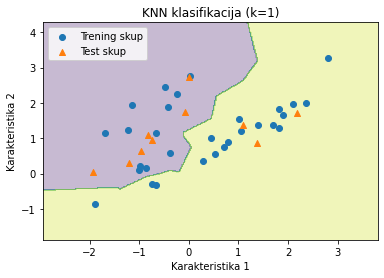

In [7]:
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)

# Trening podaci
plt.scatter(X_train[:, 0], X_train[:, 1],
            marker='o', label="Trening skup")

# Test podaci
plt.scatter(X_test[:, 0], X_test[:, 1],
            marker='^', label="Test skup")

plt.xlabel("Karakteristika 1")
plt.ylabel("Karakteristika 2")
plt.legend()
plt.title("KNN klasifikacija (k=1)")

plt.show()

Za dvodimenzionalne skupove podataka možemo prikazati predikciju za test tačke u xy-ravni. Površinu ravni bojimo prema klasi koja bi bila dodeljena tački u toj oblasti, što nam omogućava da vizuelno sagledamo granicu odlučivanja, liniju koja razdvaja oblasti gde algoritam dodeljuje klasu 0 od oblasti gde dodeljuje klasu 1. Oblast koja je obojena žutom bojom predstavlja zonu u kojoj model predviđa klasu 0, dok je ljubičastom bojom prikazana oblast koja odgovara klasi 1. Na grafiku su dodatno prikazane i tačke trening i test skupa podataka, čime se jasno vidi kako su se podaci grupisali u odnosu na granicu odlučivanja modela.

---

Dodaćemo tri nove tačke podataka, koje će biti prikazane u obliku zvezdica. Za svaku od njih označićemo najbližu tačku iz trening skupa. Prema principu algoritma najbližeg suseda, predikcija za svaku novu tačku biće jednaka klasi njene najbliže tačke iz trening podataka.

Zatim ćemo za te tri nove tačke izvršiti predviđanje klase primenom ovog pravila.

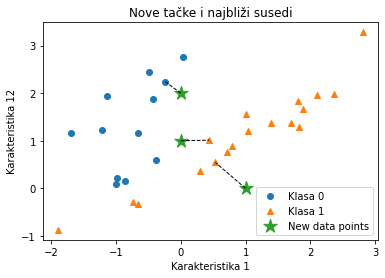

In [8]:
# Tri nove tačke (zvezdice)
X_new = np.array([
    [0, 2],
    [0, 1],
    [1, 0]
])

# KNN algoritam korak po korak
for x_new in X_new:

    # Euklidske udaljenosti
    distances = np.linalg.norm(X_train - x_new, axis=1)

    # Najbliži sused
    nearest_index = np.argmin(distances)
    nearest_point = X_train[nearest_index]
    predicted_label = y_train[nearest_index]

    # Iscrtavanje linije do najbližeg suseda
    plt.plot([x_new[0], nearest_point[0]],
             [x_new[1], nearest_point[1]],
             'k--', linewidth=1)

# Iscrtavanje trening podataka
plt.scatter(X_train[y_train == 0, 0],
            X_train[y_train == 0, 1],
            marker='o',
            label="Klasa 0")

plt.scatter(X_train[y_train == 1, 0],
            X_train[y_train == 1, 1],
            marker='^',
            label="Klasa 1")

# Iscrtavanje novih tačaka kao zvezdice
plt.scatter(X_new[:, 0],
            X_new[:, 1],
            marker='*',
            s=200,
            label="New data points")

plt.xlabel("Karakteristika 1")
plt.ylabel("Karakteristika 12")
plt.legend()
plt.title("Nove tačke i najbliži susedi")

plt.show()


Umesto da posmatramo samo jednog, najbližeg suseda, možemo uzeti u obzir proizvoljan broj suseda, koji označavamo sa $k$. Upravo po tom parametru algoritam nosi naziv $k$-najbližih suseda ($k$-NN).

Kada koristimo više od jednog suseda ($k > 1$), klasa se određuje postupkom glasanja:

- Za svaku novu tačku algoritam pronalazi $k$ najbližih suseda iz trening skupa.  
- Zatim se prebrojava koliko tih suseda pripada kojoj klasi (npr. koliko ih je u Klasi $0$, a koliko u Klasi $1$).  
- Novoj tački se dodeljuje većinska klasa, ona koja se najčešće javlja među tih $k$ suseda.  

U narednom primeru postavićemo parametar na $k = 3$ kako bismo praktično ilustrovali princip većinskog odlučivanja.


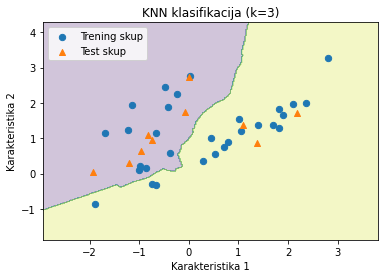

In [9]:
# KNN model sa 3 najbliža suseda
knn = KNeighborsClassifier(n_neighbors=3)

# Treniranje modela
knn.fit(X_train, y_train)

# Kreiranje mreže tačaka za decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predikcija na mreži
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Vizuelizacija decision boundary
plt.contourf(xx, yy, Z, alpha=0.25)

# Trening podaci
plt.scatter(X_train[:, 0], X_train[:, 1],
            marker='o',
            label='Trening skup',
            s=40)

# Test podaci
plt.scatter(X_test[:, 0], X_test[:, 1],
            marker='^', label="Test skup")


plt.xlabel("Karakteristika 1")
plt.ylabel("Karakteristika 2")
plt.title("KNN klasifikacija (k=3)")
plt.legend()
plt.show()


Pronalaženje suseda: Koristi se funkcija kneighbors(), koja za svaku od tri nove tačke određuje tačno $k=3$ najbližih suseda iz trening skupa. Ova funkcija vraća vrednosti udaljenosti do suseda i njihove indekse u skupu podataka. Klasa se određuje postupkom glasanja. Za svaku novu tačku algoritam pronalazi $k$ najbližih suseda iz trening skupa, a zatim se prebrojava broj suseda koji pripadaju svakoj klasi. Novoj tački se dodeljuje klasa koja je najzastupljenija među tih $k$ suseda, odnosno većinska klasa. U narednom primeru koristi se parametar $k=3$ radi praktične ilustracije principa većinskog odlučivanja.

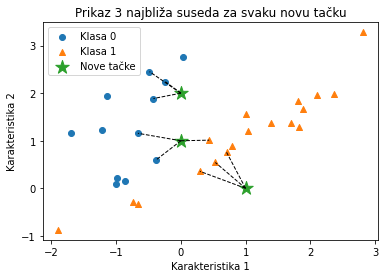

In [10]:
from sklearn.neighbors import NearestNeighbors

# Model za pronalaženje najbližih suseda
nbrs = NearestNeighbors(n_neighbors=3)
nbrs.fit(X_train)

# Pronalaženje 3 najbliža suseda za svaku novu tačku
distances, indices = nbrs.kneighbors(X_new)

# Iscrtavanje trening podataka
plt.scatter(X_train[y_train == 0, 0],
            X_train[y_train == 0, 1],
            marker='o',
            label="Klasa 0")

plt.scatter(X_train[y_train == 1, 0],
            X_train[y_train == 1, 1],
            marker='^',
            label="Klasa 1")

# Iscrtavanje novih tačaka
plt.scatter(X_new[:, 0],
            X_new[:, 1],
            marker='*',
            s=200,
            label="Nove tačke")

# Crtanje linija do 3 najbliža suseda
for i, new_point in enumerate(X_new):

    for neighbor_idx in indices[i]:
        neighbor_point = X_train[neighbor_idx]

        plt.plot(
            [new_point[0], neighbor_point[0]],
            [new_point[1], neighbor_point[1]],
            'k--',
            linewidth=1
        )

plt.xlabel("Karakteristika 1")
plt.ylabel("Karakteristika 2")
plt.title("Prikaz 3 najbliža suseda za svaku novu tačku")
plt.legend()
plt.show()

Kao i u prethodnom primeru, predviđena klasa za novu tačku prikazana je simbolom zvezdice. Može se uočiti da predikcija za novu tačku (0, 1) nije ista kao u slučaju kada je korišćen samo jedan najbliži sused ($k=1$). Konkretno, tačka $(0,1)$ sada pripada klasi 0 prema principu većinskog glasanja, jer su dva od tri najbliža suseda iz klase 0. Do ove razlike dolazi jer veći broj suseda uključenih u proces odlučivanja čini model stabilnijim i manje osetljivim na pojedinačna odstupanja u podacima. 

---

Iako je ilustracija prikazana na primeru binarne klasifikacije, ovaj metod se može primeniti i na probleme sa većim brojem klasa. U slučaju višeklasne klasifikacije, postupak ostaje isti: za svaku novu tačku prebrojava se broj suseda koji pripadaju svakoj klasi, a novoj tački se dodeljuje klasa koja je najzastupljenija među susedima.

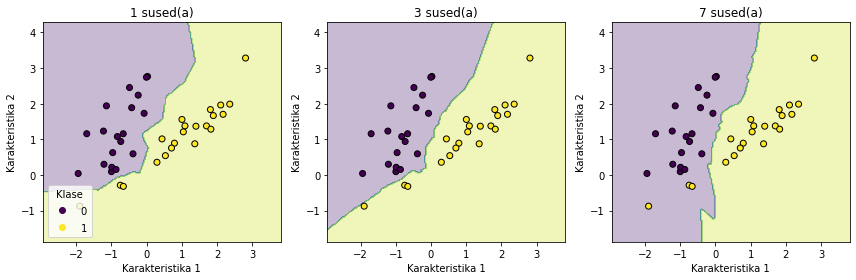

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Vrednosti k koje želimo da prikažemo
neighbors_list = [1, 3, 7]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Granice prostora za granicu odlučivanja
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

for n_neighbors, ax in zip(neighbors_list, axes):

    # Treniranje KNN modela
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X, y)

    # Predikcija na mreži tačaka
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Granica odlučivanja
    ax.contourf(xx, yy, Z, alpha=0.3)

    # Originalni podaci
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    ax.set_title(f"{n_neighbors} sused(a)")
    ax.set_xlabel("Karakteristika 1")
    ax.set_ylabel("Karakteristika 2")

# Legenda
axes[0].legend(*scatter.legend_elements(), title="Klase", loc=3)

plt.tight_layout()
plt.show()


Promena oblika granice odlučivanja u prikazanom eksperimentalnom rezultatu posledica je strukture i distribucije korišćenog skupa podataka. U implementaciji k-najbližih suseda algoritma korišćenjem biblioteke scikit-learn, klasifikacija nove instance zasniva se na većinskom glasanju među $k$ najbližih trening primera. U analiziranom grafiku, skup podataka je sintetički generisan i sadrži lokalne koncentracije tačaka različitih klasa, što utiče na izgled granice odlučivanja.

Za $k=1$ granica odlučivanja je izrazito lokalna i prati pojedinačne trening instance, zbog čega se formiraju složeniji i nepravilniji regioni klasifikacije. Povećanjem broja suseda na $k=7$, model prilikom predikcije uzima u obzir veći broj okolnih tačaka, što dovodi do formiranja prelaznih zona između klasa. Iako se u teoriji često očekuje da veće vrednosti $k$ proizvedu glatkiju granicu odlučivanja, u ovom eksperimentalnom slučaju granica može izgledati strmije i sa izraženijim lokalnim oštrinama. Ovo je posledica neravnomerne prostorne raspodele instanci u skupu podataka, kao i činjenice da algoritam k-najbližih suseda direktno zavisi od lokalne gustine podataka.

U nastavku je data studija slučaja gde je prikazana praktična primena $k$-najbližih suseda koristeći biblioteku `scikit-learn`, kao i analiza performansi modela na realnom skupu podataka, uz razmatranje uticaja parametra $k$ na tačnost klasifikacije.

```{admonition} Za one koji žele da znaju više...
:class: seealso


- Osim klasičnih metrika rastojanja, postoje i drugi načini za merenje sličnosti između podataka. U tom smislu, u analizi o ekspresiji gena dobijenih mikročipovima, k-NN algoritam se primenjuje uz korišćenje Pirsonovog i Spirmanovog koeficijenata korelacije, umesto standardnih metrika rastojanja, pogledajte rad [1].

- Iako je naivni KNN algoritam jednostavan za implementaciju, on je računski jako zahtevan, pogotovu za velike skupove podataka, jer se izračunavanju rastojanja između test primera i svakog uzorka u bazi. Da bi se olakšala primena KNN algoritam u praksi, koriste se optimizovani algoritmi za pretragu najbližih suseda koji značajno smanjuju broj potrebnih poređenja, čime se poboljšava efikasnost algoritma čak i pri radu sa velikim brojem podataka. Pogledajte na primer [2], [3], [4].

- U slučaju rada sa bazom podataka sa velikim brojem dimenzija, standardna praksa podrazumeva primenu tehnika za redukciju dimenzionalnosti pre same implementacije k-NN algoritma kako bi se izbeglo prokletstva dimenzionalnosti (engl. curse of dimensionality), [5].

```

<br>

## Studije slučaja

🧩 Ocena kreditnog rizika

U cilju ilustracije ilustracije praktične upotrebe algoritma k-najbližih suseda, biće prikazana njegova primena u Pajton okruženju 

Koristimo bazu *German Credit Dataset* koja je javno dostupna, i direktno je učitavamo iz UCI Machine Learning repozitorijuma koristeći funkciju `fetch_openml` putem biblioteke scikit-learn. Ovim pristupom proces učitavanja podataka je automatizovan, bez potrebe za ručnim preuzimanjem i lokalnim skladištenjem baze podataka. Posmatrana baza sadrzi 1000 instanci opisanih putem 20 numeričkih i kategorijskih atributa o karakteristikama klijenata i njihovim kreditnim zahtevima. Zbog svoje strukture ova baza se često koristi kao primer za primenu klasifikacionih algoritama. Ciljna promenljiva u ovom skupu podataka je binarna i klasifikuje klijente na "dobre" ili "loše" platiše na osnovu procenjenog kreditnog rizika, tj. procjenjuje se da li klijent pripada grupi niskog ili visokog kreditnog rizika.


Skup svih 20 ulaznih promenljivih (atributa) su opisane u nastavku:
```{table} Opis ulaznih promenljivih 
:label: point_spec
:align: center
:header-rows: 1

| #  | Originalni naziv | Opis na srpskom | Tip podatka| 
|----|-----------------|----------------|------------|
| 1  | Status of existing checking account | Status tekućeg računa klijenta | Kategorički |
| 2  | Duration in month | Trajanje kredita (u mesecima) | Numerički |
| 3  | Credit history | Kreditna istorija klijenta | Kategorički |
| 4  | Purpose | Svrha kredita | Kategorički |
| 5  | Credit amount | Iznos kredita | Numerički |
| 6  | Savings account/bonds | Status štednog računa ili obveznica | Kategorički |
| 7  | Present employment since | Dužina trenutnog zaposlenja | Kategorički |
| 8  | Installment rate in percentage of disposable income | Rata kredita kao procenat raspoloživog dohotka | Numerički |
| 9  | Personal status and sex | Lični status i pol | Kategorički |
| 10 | Other debtors / guarantors | Ostali dužnici ili jemci | Kategorički |
| 11 | Present residence since | Dužina boravka na trenutnoj adresi | Numerički |
| 12 | Property | Vrsta imovine | Kategorički |
| 13 | Age in years | Starost klijenta (u godinama) | Numerički |
| 14 | Other installment plans | Ostali kreditni aranžmani | Kategorički |
| 15 | Housing | Status stanovanja | Kategorički |
| 16 | Number of existing credits at this bank | Broj postojećih kredita u istoj banci | Numerički |
| 17 | Job | Zanimanje | Kategorički |
| 18 | Number of people being liable to provide maintenance for | Broj izdržavanih lica | Numerički |
| 19 | Telephone | Posedovanje telefona | Kategorički |
| 20 | Foreign worker | Status stranog radnika | Kategorički |
 ```

**Ciljna varijabla (klasifikacija rizika):**

- **1 (Nizak rizik):** klijent sa stabilnim kreditnim profilom i minimalnim stepenom rizika.  
- **2 (Visok rizik):** klijent sa povišenim stepenom rizika i potencijalnom nesolventnošću.


*Priprema radnog okruženja i učitavanje biblioteka* 

Pre same implementacije modela potrebno je učitati odgovarajuće softverske biblioteke. U nastavku se učitavaju sve biblioteke neophodne za rad, zajedno sa njihovim skraćenim nazivima, koji će se koristiti radi jednostavnijeg i preglednijeg pozivanja njihovih funkcija i atributa tokom implementacije. 


* **Pandas (`pd`)**: Primarna biblioteka za rad sa tabelarnim podacima (DataFrames). Koristi se za učitavanje podataka (na primer iz `.csv` datoteka), njihovo čišćenje i efikasnu manipulaciju tabelarnim strukturama. Skraćenica `pd` predstavlja standardnu konvenciju u Python zajednici.

* **NumPy (`np`)**: Osnovna biblioteka za efikasan rad sa višedimenzionalnim nizovima (arrays) i izvođenje brzih numeričkih i matematičkih operacija. Skraćenica `np` predstavlja standardnu konvenciju u Python zajednici. Iako se NumPy ponekad ne koristi direktno u kodu, biblioteka Pandas se u velikoj meri oslanja na njega u pozadini čineći rad sa nizovima i tabelarnim podacima znatno efikasnijim.

* **Scikit-learn (`sklearn`)**: Najznačajnija biblioteka za klasično mašinsko učenje, iz koje u ovom koraku koristimo:
    * `KNeighborsClassifier`: Algoritam za izgradnju modela k-najbližih suseda za klasifikaciju.
    * `train_test_split`: Alat za podelu podataka na podskupove za obuku i testiranje.
    * `metrics`: Funkcije za preciznu evaluaciju performansi (tačnost, preciznost, odziv) obučenog modela. Modul `sklearn.metrics` se učitava kako bi mogli da koristimo metrike pomoću kojeg radimo evaluaciju našeg modela. `classification_report` nam daje izveštaj koji sumira performansama klasifikacije, ne otkriva samo učestalost grešaka, već i kakve greške model pravi.
    * `fetch_openml`: Funkcija automatizuje proces preuzimanja podataka koristeći API poziv ka OpenML repozitorijumu umesto manuelnog preuzimanja fajlova. Funkcija `fetch_openml` pripada biblioteci `scikit-learn` u okviru modlua `sklearn.datasets`, i koristi se za automatizovano preuzimanje javno dostupnih skupova podataka sa repozitorijuma *OpenML* i njihovo direktno učitavanje u Python okruženje.
        - Podacima se pristupa putem naziva, jedinstvenog identifikacionog broja ili specifične specifične verzije skupa podataka.
        - Ova funkcija automatski učitava podatke u `Pandas DataFrame` (podrazumevano) ili `NumPy` nizove (podešavajem parametra `as_frame` na `False`). 
    * `StandardScaler`: Standardizuje numeričke podatke tako da imaju srednju vrednost 0 i standardnu devijaciju 1. 

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

*Definisanje imena kolona*

Radi bolje čitljivost koda, u ovoj fazi manuelno dodeljujemo deskriptivna imena svakom atributu.

In [2]:
columns = [
    "Status_racuna", "Trajanje_kredita", "Kreditna_istorija", "Svrha",
    "Iznos_kredita", "Stednja", "Radni_staz", "Stopa_rata",
    "Licni_status", "Drugi_duznici", "Vreme_stanovanja",
    "Imovina", "Starost", "Drugi_krediti",
    "Stanovanje", "Broj_kredita",
    "Zaposlenost", "Broj_izdrzavanih", "Telefon", "Strani_radnik",
    "Klasa"
]

Učitavanje skupa podataka

U ovom koraku definišemo internet adresu (engl. URL) koja vodi do German Credit skupa podataka. Ovaj dataset je deo čuvenog UCI Machine Learning Repository arhiva.

In [3]:
VebAdresa = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

Učitavamo skup podataka u Pandas DataFrame, pri čemu koristimo `sep=" "` da označimo da su vrednosti odvojene razmakom. Postavljanjem parametra `header=None`označavamo da dataset ne sadrži red sa imenima kolona, dok postavljanjem parametra `names=columns` dodeljujemo nazive kolona onako kako su u prethodnom redu definisani i smešteni u niz `columns`.

Ako se u zagradama ne navede broj, metoda `baza.head()` podrazumevano prikazuje prvih 5 redova skupa podataka.  
Ukoliko se u zagradama navede broj, prikazuju se prvih onoliko redova koliko je zadato. Analogno tome, metoda `baza.tail()` prikazuje poslednjih 5 redova ako broj nije preciziran, odnosno poslednjih onoliko redova koliko je navedeno u zagradama.

In [4]:
baza = pd.read_csv(VebAdresa, sep=" ", header=None, names=columns)
baza.head()

C:\Users\Dragan Azdejkovic\Miniconda3\Lib\ssl.py:524: UserWarning: Bad certificate in Windows certificate store: not enough data: cadata does not contain a certificate (_ssl.c:4219)
  warnings.warn(f"Bad certificate in Windows certificate store: {exc!s}")


,Status_racuna,Trajanje_kredita,Kreditna_istorija,Svrha,Iznos_kredita,Stednja,Radni_staz,Stopa_rata,Licni_status,Drugi_duznici,...,Imovina,Starost,Drugi_krediti,Stanovanje,Broj_kredita,Zaposlenost,Broj_izdrzavanih,Telefon,Strani_radnik,Klasa
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Kada pozovemo `baza.describe()` dobijamo statistički sažetak numeričkih kolona skupa podataka:

- **count**: Broj ne-nedostajućih vrednosti u koloni.  
- **mean**: Srednja vrednost (prosek) kolone.  
- **std**: Standardna devijacija (koliko se vrednosti prosečno udaljavaju od srednje vrednosti).  
- **min**: Najmanja vrednost u koloni.  
- **25%**: Donji kvartil (prva četvrtina podataka).  
- **50%**: Medijana (srednja vrednost).  
- **75%**: Gornji kvartil (treća četvrtina podataka).  
- **max**: Najveća vrednost u koloni.  

> Napomena: Standardna metoda `describe()` analizira isključivo **numeričke kolone**. Kako biste dobili uvid i u **kategoričke podatke**, koristite argument `include='all'`, što dodatno vraća:
> - **unique** – broj jedinstvenih vrednosti u koloni
> - **top** – najčešća vrednost (moda)
> - **freq** – frekfencija ponavljanja najčešće vrednosti 

In [5]:
baza.describe()

,Trajanje_kredita,Iznos_kredita,Stopa_rata,Vreme_stanovanja,Starost,Broj_kredita,Broj_izdrzavanih,Klasa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


Pozovanje metode`.info()` jedan je od prvih koraka u analizi podataka. Njenim pozivanjem dobijamo izveštaj o strukturi posmatranog skupa podataka, uključujući tip objekta, opsega indeksa, broj redova, listu kolona, broj popunjenih vrednosti za svaki atribut (što nam omogućava odentifikaciju nedostajućih vrednosti), tip podataka svake kolone, količinu memorije koju zauzima skup podataka. 

> Metod `.info()` je koristan za brzu proveru nedostajućih vrednosti i tipova podataka u skupu podataka.

In [6]:
baza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Status_racuna      1000 non-null   object
 1   Trajanje_kredita   1000 non-null   int64 
 2   Kreditna_istorija  1000 non-null   object
 3   Svrha              1000 non-null   object
 4   Iznos_kredita      1000 non-null   int64 
 5   Stednja            1000 non-null   object
 6   Radni_staz         1000 non-null   object
 7   Stopa_rata         1000 non-null   int64 
 8   Licni_status       1000 non-null   object
 9   Drugi_duznici      1000 non-null   object
 10  Vreme_stanovanja   1000 non-null   int64 
 11  Imovina            1000 non-null   object
 12  Starost            1000 non-null   int64 
 13  Drugi_krediti      1000 non-null   object
 14  Stanovanje         1000 non-null   object
 15  Broj_kredita       1000 non-null   int64 
 16  Zaposlenost        1000 non-null   object
 

*Binarizacija ciljne klase; Razdvajanje podataka na ulazne atribute i izlazne labele*


1. **Binarizacija ciljne klase**: U posmatranoj bazi ciljna promenljiva uzima vrednosti `1` (dobar kreditni rizik) i `2` (loš kreditni rizik). Koristeci metodu `.map()` izvršićemo prekodiranje ovih vrednosti `1` u `1` (dobar klijent), i `2` u `1` (rizičan klijent) radi usklađivanja sa standardima binarne klasifikacije.

2. **Razdvajanje na ulazne atribute i izlazne labele**:
    * **Matrica atributa (`X`)**: Izdvajanjem kolone "`"Klasa"` iz skupa podataka formiramo matricu atributa (nezavisnih promenljivih). Ovi podaci predstavljaju ulazne parametre ($X$) na osnovu kojih model uči da prepoznaje obrasce i donosi predviđanja. 
    * **Izlazna labela (`y`)**: Kolona `"Klasa"` se izdvaja kao **zavisna promenljiva**, odnosno ciljni vektor ($y$), čija se vrednost predviđa na osnovu ulaznih podataka. U kontekstu mašinskog učenja, ovaj vektor predstavlja "labelu" ili tačan odgovor na osnovu kojeg model uči da prepoznaje obrasce i vrši klasifikaciju novih primera.

In [7]:
# Transformacija izlazne labele u binarni oblik
baza["Klasa"] = baza["Klasa"].map({1: 1, 2: 0})

X = baza.drop("Klasa", axis=1)
y = baza["Klasa"]

Primenjujemo funkciju `pd.get_dummies` za transformaciju kategoričkih promenljivih u numerički format pogodan za modele mašinskog učenja.
 - *One-Hot Encoding*: Svaka različita kategorija iz originalne kolone dobija zasebnu indikator promenljivu, pri čemu vrednost 1 označava prisustvo određene kategorije, a 0 njeno odsustvo.
 - *Uklanjanje prve kategorije (`drop_first=True`)*: Ova opcija eliminiše jednu od novonastalih kolona za svaku originalnu varijablu kako bi se izbegla multikolinearnost.

In [8]:
# One-Hot Encoding kategorijskih promenljivih
X_encoded = pd.get_dummies(X, drop_first=True)

Bazu možemo učitati i koristeći funkciju `fetch_openml()`, učitali bismo bazu podataka 'German Credit' pozivanjem sledeće linije koda: 

data = fetch_openml(name="credit-g", version=1)


```{admonition} Razlika između nove i starije verzije 'scikit-learn'


:class: seealso
Napomena o argumentu `as_frame` u `fetch_openml()`

U novijim verzijama biblioteke **scikit-learn**, funkcija `fetch_openml()` podržava argument `as_frame=True`, koji omogućava da se podaci odmah učitaju u **Pandas DataFrame** i Series:

```python
data = fetch_openml(name="credit-g", version=1, as_frame=True)

X = baza.data
y = baza.target
```

*Podela na skup za treniranje i skup za testiranje. Standardizacija numeričkih atributa*

* Parametar `test_size=0.3` razdavaja skup podataka tako da će 30% podataka biti sačuvano za testiranje, dok će se 70% koristiti za obuku modela. 

* Parametar `random_state` se koristi kako bi svaki put kada iznova pokrenemo kod podela podataka na trening i test skup bila uvek ista, što takođe omogućava reproduktivnost. Ovakva fiksna podela je korisna jer osigurava  korišćenje istog skupa treniranje i istog skupa za testiranje, čime postižemo da su rezultati različitih verzija modela direktno uporedivi. Napomenimo da se umesto `42` može se koristiti bilo koji drugi broj, i naravno dobijammo drugačiju podelu podataka. U sekciji "Stabla odlučivanja" možete pročitati zanimljivost zašto se baš `random_state=42` često pojavljuje.

* Drugim rečima, `random_state` **fiksira generator slučajnih brojeva** koji se koristi za nasumičnu podelu skupa, pa su rezultati predvidljivi i ponovljivi.

* Korišćenjem parametra `stratify`, obezbeđujemo da distribucija klasa u skupu za testiranje održava identične proporcije klasa kakve postoje u izvornoj populaciji podataka.

* `StandardScaler` je alat iz biblioteke `scikit-learn` koji vrši skaliranje, tj. koji numeričke podatke transformiše tako da njihova srednja vrednost bude $0$, a standardna devijacija $1$. Kako koristi metrike rastojanja algoritam KNN je osetljiv na skalu ulaznih podataka, pa je neophodno izvršiti standardizaciju kako bi svi atributi imali ravnomeran doprinos u odlučivanju

* Nakon standardizacije, primenjuje se metoda `fit_transform` nad trenažnim podacima (`X_train`). Ovaj korak je dvostruk:  
    > **Fit faza:** Algoritam analizira skup za treniranje kako bi izračunao aritmetičku sredinu ($\mu$) i standardnu devijaciju ($\sigma$) za svaku karakteristiku; 
    
    > **Faza transformacije:** Koristeći ove parametre, vrši se matematička transformacija podataka tako da se svako obeležje svede na standardnu normalnu raspodelu.
    > Na skupu za testiranje primenjuje metodu `.transform()`primenjujući srednju vrednost i varijansu koje su naučena na skupu za treniranje. Ovde ne koristimo `fit` jer u realnim uslovima testni podaci su nepoznati.    
---

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Standardizacija numeričkih atributa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

*Inicijalizacija i obuka KNN modela*

Kreiramo instancu klase `KNeighborsClassifier` uz definisanje ključnih hiperparametara:

* **`n_neighbors=5`**: Određujemo da će model donositi odluku na osnovu 5 najbližih suseda. U ovom koraku ćemo eksperimentalno postaviti vrednost parametra $k=5$ kako bismo demonstrirali rad algoritma i analizirali njegove performanse na konkretnom primeru. Detaljnija analiza uticaja parametra $k$ na ponašanje modela, kao i metode za izbor njegove optimalne vrednosti, biće razmatrane u nastavku.

    * Biramo neparan broj kako bismo smanjili verovatnoću "nerešenog" ishoda pri glasanju između dve klase. 
    * **Šta se dešava ako je ipak nerešeno?** U situacijama sa više klasa (npr. rezultat glasanja je $2:2:1$), ili kada je broj suseda paran ($2:2$), `scikit-learn` biblioteka najčešće rešava problem na jedan od dva načina:
        1. **Težinsko glasanje:** Ako je podešen parametar `weights='distance'`, prednost dobija klasa čiji su susedi fizički bliži upitnoj tački.
        2. **Redosled klasa:** Ako su težine jednake (`uniform`), algoritam obično bira klasu koja se prva pojavljuje u redosledu (najčešće ona sa manjim indeksom ili koja je prva u labelama).
* **`metric="euclidean"`**: Koristimo **Euklidsku udaljenost** kao standardnu metriku za izračunavanje prostorne bliskosti između tačaka. S obzirom na to da smo prethodno skalirali podatke, ova metrika će dati stabilne i pouzdane rezultate.



*Treniranje modela (`.fit` metod)*
Pozivom metode `.fit(X_train_scaled, y_train)`, model se obučava na standardizovanom trenažnom skupu:

1.  **Mapiranje podataka:** Za razliku od algoritama koji uče složene matematičke funkcije, KNN je tzv. **"lenji učenik"** (*lazy learner*). On u ovoj fazi jednostavno skladišti (indeksira) trenažne primere i njihove labele (`y_train`) u memoriju.
2.  **Spremnost za predviđanje:** Nakon izvršavanja ove linije koda, klasifikator je spreman da na osnovu memorisanih podataka analizira nove, testne uzorke i dodeli im odgovarajuću klasu.

In [11]:
# Definisanje KNN klasifikatora 
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean") 
# Treniranje modela 
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Pre nego što ocenimo performanse modela, demonstriramo identifikaciju suseda i mehanizam identifikacije suseda i način na koji model, kroz proces glasanja, donosi konačnu odluku za konkretan test primer. 

Algoritam KNN, kao metoda lenjog učenja, ne gradi model unapred, već čeka trenutak predikcije kako bi uporedio novi podatak sa postojećima, a proces predikciju se zasniva na tri ključna koraka:

1. Izračunavanje rastojanja između test uzorka i svakog pojedinačnog primera iz trening skupa.
   
2. Pronalaženje $k$ najsrodnijih suseda na osnovu prethodno izračunatih distanci.
   
3. Finalna klasifikacija se vrši putem **većinskog glasanja**, gde klasa koja je najzastupljenija među susedima određuje pripadnost novog podatka.

> **Napomena:** Iako je k-NN izuzetno fleksibilan, njegova priroda nosi određene izazove pri radu sa velikim skupovima podataka:
    - Memorijska zahtevnost: Model mora da čuva čitav skup podataka u memoriji.
    - Računarska složenost: Pri svakoj novoj predikciji, algoritam mora da "pretraži" bazu i izračuna udaljenosti, što zahteva značajnu procesorsku snagu.

Za razliku od parametarskih modela, KNN ne formira eksplicitnu funkciju odlučivanja tokom treniranja, već odluku donosi u realnom vremenu. U nastavku ćemo praktično demonstrirati ovaj mehanizam identifikacije suseda i prikazati kako model, kroz proces poređenja i glasanja, donosi konačnu odluku za ovaj obrađen primer.

*Analiza mehanizma predikcije*

Pre nego što model donese konačnu odluku, mehanizam njegovog rada možemo istražiti pomoću metode `.kneighbors()`. Ovaj postupak se sastoji od sledećih koraka:

* `.reshape(1, -1)`: budući da `scikit-learn` očekuje dvodimenzionalni niz (matricu) kao ulaz, transformiše jedan test primer u oblik (1 red, n kolona).
    
* `.kneighbors()`: 
    Ovo je ključna funkcija koja nam omogućava transparentnost modela. Ona ne vraća klasu, već dva bitna niza podataka:
    1. `distances`: Numeričke vrednosti rastojanja između test primera i njegovih $k$ najbližih suseda.
    2. `indices`: Redne brojeve (indekse) tih suseda u originalnom trening skupu.

---

*Interpretacija rezultata*
Pomoću ovih podataka možemo precizno definisati:
1. *Lokalni kontekst:* Koji tačno uzorci iz baze znanja (trening skupa) direktno utiču na klasifikaciju našeg primera.
2. *Stepen sličnosti:* Koliko su ti susedi zapravo blizu (slični) posmatranom primeru, što nam pomaže da procenimo pouzdanost same predikcije.

In [12]:
# Biramo prvi primer iz test skupa
test_sample = X_test_scaled[0].reshape(1, -1)

# Pronalazimo 5 najbližih suseda
distances, indices = knn.kneighbors(test_sample)

print("Indeksi najbližih suseda:", indices)
print("Rastojanja do suseda:", distances)


Indeksi najbližih suseda: [[494 224 425 144 282]]
Rastojanja do suseda: [[4.92640798 4.97689824 5.18098496 5.21376189 5.64843548]]


*Kako model donosi odluku?*
U ovom koraku vršimo uvid u "glasačko telo" našeg algoritma:
1. **Analiza suseda:** Identifikovali smo klase za 5 primera iz trening skupa koji su najsličniji našem test primeru.
2. **Finalna predikcija:** Model agregira ove vrednosti i dodeljuje klasu koja se najčešće pojavljuje među susedima.

In [13]:
# Koje klase imaju susedi?
neighbor_classes = y_train.iloc[indices[0]]
print("Klase najbližih suseda:")
print(neighbor_classes)

Klase najbližih suseda:
459    1
534    1
66     1
679    1
901    1
Name: Klasa, dtype: int64


In [14]:
#Možemo proveriti i samu predikciju
prediction = knn.predict(test_sample)
print("Predviđena klasa:", prediction)

Predviđena klasa: [1]


#### Predviđanje i evaluacija performansi modela

Nakon što je model usvojio obrasce iz trenažnih podataka, prelazimo na završnu fazu: testiranje na novim podacima. Ovaj proces nam služi za eksternu evaluaciju, jer nam omogućava da kvantifikujemo performanse klasifikatora u realnim uslovima primene.

**Generisanje predikcija (`.predict`)**
„Primenom metode `.predict(X_test_scaled)`, klasifikator vrši evaluaciju testnih uzoraka identifikacijom $k=5$ prostorno najbližih instanci u trenažnom skupu. Konačna klasifikacija svakog primera, na osnovu većine glasova, dodeljuje mu labelu ( "dobar" ili "rizičan" klijent).

 Metrika ukupne tačnosti (engl. Accuracy)
Funkcija `accuracy_score` nam daje najbrži uvid u performanse modela. Ona predstavlja procenat tačno klasfikovanih instanci.

> **Napomena:** Iako je tačnost koristan indikator, ona može biti varljiva kod nebalansiranih skupova podataka, zbog čega je neophodna detaljnija analiza.



*Izveštaj o klasifikaciji (engl. Classification Report)*  

Za dublje razumevanje performansi, koristimo `classification_report`, koji dekomponuje uspeh modela po svakoj klasi posebno kroz tri ključna indikatora:

* **Preciznost (engl. Precision) :** Pokazuje koliko je model pouzdan kada klijenta označi kao rizičnog.
* **Odziv (engl. Recall):** Pokazuje sposobnost modela da identifikuje sve stvarne rizične klijente u skupu podataka.
* **F1 -skor (engl. F1-score):** Predstavlja harmonijsku sredinu preciznosti i odziva, pružajući balansiranu ocenu kvaliteta klasifikacije.

In [16]:
# Predikcija
y_pred = knn.predict(X_test_scaled)

# Tačnost
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detaljan izveštaj
print(classification_report(y_test, y_pred))

Accuracy: 0.7166666666666667
              precision    recall  f1-score   support

           0       0.54      0.34      0.42        90
           1       0.76      0.88      0.81       210

    accuracy                           0.72       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.72      0.70       300



**  📊 Interpretacija rezultata. Evaluacija uspešnosti klasifikacionog modela.**

Iako ukupna tačnost modela iznosi **72,33%**, za pravilnu interpretaciju performansi potrebno je analizirati metrike **precision** i **recall**, koje pružaju detaljniji uvid u ponašanje klasifikatora.

> **Preciznost (engl. Precision)** predstavlja meru pouzdanosti pozitivnih predikcija.  
> Pokazuje koliki procenat primera koje je model označio kao pripadajuće određenoj klasi zaista i pripada toj klasi.

* Vrednosti precision kreću su 0.56 za klasu rizičnih klijenata i 0.76 za klasu kreditno sposobnih klijenata.  
* Ponderisani prosek iznosi **0.70**.  
* To znači da je približno 70% svih pozitivnih predikcija modela tačno.

> **Odziv (engl. Recall)** meri sposobnost modela da prepozna stvarne primere određene klase.  
> Ova metrika pokazuje koliki procenat stvarnih primera model uspešno identifikuje.

* Vrednosti recall kreću se od 0.36 za klasu rizičnih klijenata i 0.88 za klasu kreditno sposobnih klijenata.  
* Ponderisani prosek iznosi **0.72**.  
* To znači da model u proseku prepoznaje oko 72% stvarnih primera.

Makro proseci (**precision = 0.66**, **recall = 0.62**) ukazuju da performanse nisu potpuno ujednačene, dok ponderisani proseci (**precision = 0.70**, **recall = 0.72**) odražavaju ukupno ponašanje modela na celokupnom skupu podataka.

---

> **Podrška (engl. support)** predstavlja broj primera klase u skupu za testiranje, što svakako utiče na rezultate klasifikacije, i iz dobijenih rezultatat u tabeli mozemo zakljuciti: 
    > Disbalans klasa: Uočava se značajan disbalans klasa unutar skupa: dok je kategorija dobrih platiša zastupljena sa 210 primera, rizična grupa obuhvata svega 90 uzoraka, što ukazuje na jasan odnos od 2,3 : 1 u korist pozitivnih primera.
    
   > Pristrasnost KNN modela: Zbog mehanizma odlučivanja koji se oslanja na sličnost sa najbližim susedima, KNN model je pristrasan ka brojnijoj klasi. Dominacija podataka o pouzdanim platišama osigurava njihov visok odziv, ali direktno uzrokuje niže performanse u detekciji loših platiša, jer model retko pronalazi dovoljno „loših“ suseda za ispravnu klasifikaciju.


>  **Makro F1-skor naspram Težinskog F1-skor** Makro i težinski prosek se posmatraju zajedno kako bi se utvrdilo da li model ravnomerno ostvaruje dobre rezultate nad svim klasama.

> **Makro F1-skor (engl. Macro F1-score)** predstavlja aritmetičku sredinu F1-skorova svih klasa, pri čemu se svakoj klasi daje jednaka važnost, bez obzira na broj primera.
      * Vrednost **0.63** ukazuje da performanse modela nisu ujednačene između klasa.
      * Ova metrika je osetljiva na slabije rezultate kod manje zastupljene klase.
      * Niža vrednost sugeriše da model ima poteškoće u ravnomernom prepoznavanju svih klasa.

> **Težinski F1-skor (engl. Weighted F1-score)** uzima u obzir broj primera po klasi (support), pa su zastupljenije klase snažnije ponderisane u konačnom rezultatu.
    * Vrednost **0.70** pokazuje bolje ukupne performanse modela kada se uzme u obzir distribucija podataka.
    * Viša vrednost u odnosu na Macro F1-score ukazuje da model postiže bolje rezultate na dominantnijoj klasi.

---
 
** 🎓 Zaključak**

* Model pokazuje relativno uravnotežen odnos između precision i recall metrika na agregatnom nivou.  
* Prisutan je prostor za optimizaciju, u zavisnosti od toga da li je u primeni važnija pouzdanost pozitivnih predikcija (preciznost) ili potpunost detekcije stvarnih primera (odziv).
* Rezultati ukazuju da KNN model favorizuje većinsku klasu i ostvaruje neprihvatljivo nizak odziv za rizične klijente.
* Razlika između Makro F1-skora (0.63) i Težinskog F1-skora (0.70) sugeriše postojanje neravnomernih performansi po klasama.
* Model ostvaruje solidan ukupni rezultat, ali slabije prepoznaje jednu od klasa.
* U situacijama kada je podjednaka važnost svih klasa prioritet, relevantniji pokazatelj je Makro F1-skor.
* Kada je cilj optimizacija ukupne tačnosti u skladu sa distribucijom podataka, prikladniji je Težinski F1-skor.

* Uticaj parametra k na performanse modela *

Parametar $k$ predstavlja broj najbližih suseda koji učestvuju u procesu klasifikacije nove instance. Izbor vrednosti parametra $k$ predstavlja jedan od ključnih koraka u primeni KNN algoritma, jer direktno utiče na tačnost i pouzdanost donetih odluka. Kod malih vrednosti parametra $k$ model se snažno prilagođava trening podacima, što može povećati rizik od overfitting-a zbog osetljivosti na šum, dok povećanje $k$ smanjuje osetljivost na pojedinačne podatke, ali preveliko $k$ može izazvati underfitting i gubitak lokalnih karakteristika. U prethodnom primeru razmatran je slučaj sa $k=5$ kako bi se na jednostavan i ilustrativan način demonstrirao princip rada algoritma i mehanizam klasifikacije na osnovu najbližih suseda. Međutim, neophodno sprovesti postupak izbora optimalnog $k$. 


Optimalna vrednost parametra $k$ obično se određuje empirijski, analizom performansi modela na validacionom ili test skupu podataka, pri čemu je cilj pronaći vrednost $k$ koja obezbeđuje dobar balans između tačnosti modela i njegove sposobnosti da dobro generalizuje na nove, nepoznate podatke.

Definišemo skup kandidata za hiperparametar $k$, nakon čega se na tom skupu primenjuje postupak unakrsne validacije radi procene optimalne vrednosti parametra.

Funkcije `cross_val_score` iz biblioteke `scikit-learn`, tačnije iz modula `model_selection`, omogućava primenu unakrsne validacije (engl. cross-validation). Umesto oslanjanja na jednu podelu podataka, cilj ove metode je validacija modela na nepoznatim uzorcima, čime se izbegava subjektivnost procene koja je karakteristična za korišćenje samo jedne podele podataka na trening i test skup. Ova metoda deli skup podataka na više podskupova (*foldova*) i ciklično ih rotira, čime omogućava da svaki od njih tačno jednom preuzme ulogu testnog skupa, dok se model trenira na preostalih $K-1$ delova, što obezbeđuje objektivniju procenu kvaliteta modela. U ovom primeru posmatramo 5-fold unakrsnu validaciju, s obzirom da je broj 5 uobičajen izbor u praksi jer predstavlja dobar kompromis između pouzdanosti procene performansi i računarske složenosti, iako se u zavisnosti od prirode problema može koristiti i drugačiji broj foldova.

In [17]:
# Definisanje skupa kandidata za hiperparametar $k$
k_vrednosti = range(1, 31)

from sklearn.model_selection import cross_val_score

# Lista za čuvanje prosečnih vrednosti tačnosti dobijenih unakrsnom validacijom
UnakrsnaValidacija_tacnosti = []

# Iteracija kroz različite vrednosti parametra k
for k in k_vrednosti:
    # Inicijalizacija k-NN klasifikatora sa zadatim brojem suseda
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    
    # Izračunavanje tačnosti primenom unakrsne validacije sa pet podskupova na trening podacima
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    # Čuvanje prosečne tačnosti za datu vrednost k
    UnakrsnaValidacija_tacnosti.append(scores.mean())

Nakon evaluacije performansi modela za svaku definisanu vrednost parametra $k$ iz skupa kandidata, sledi identifikacija vrednosti $k$ koja najbolje balansira između nedovoljnog i prekomernog prilagođavanja modela.

* **`np.argmax(cv_scores)`**: Ova funkcija pronalazi indeks (poziciju) na kojoj se nalazi najveća vrednost u nizu rezultata unakrsne validacije.
* **`optimalno_k = k_vrednosti[...]`**: Koristeći pronađeni indeks, iz našeg početnog skupa kandidata izvlačimo konkretnu vrednost parametra $k$ koja je ostvarila najbolji rezultat.
* **`max(UnakrsnaValidacija_tacnosti)`**: Izračunava i prikazuje kolika je bila ta maksimalna postignuta preciznost (tačnost) tokom procesa validacije.

Literatura

[1] Jaskowiak, P. A.; Campello, R. J. G. B. “Comparing Correlation Coefficients as Dissimilarity Measures
for Cancer Classification in Gene Expression Data”. http://citeseerx.ist.psu.edu/viewdoc/summary?doi=10.1.1.
208.993''. Brazilian Symposium on Bioinformatics (BSB 2011). pp. 1–8. Retrieved 16 October 2014

[2] Weinberger, K. Q., & Saul, L. K. (2009). Distance metric learning for large margin nearest neighbor classification. Journal of machine learning research, 10(2).

[3]  Goldberger, J., Hinton, G. E., Roweis, S., & Salakhutdinov, R. (2004). Neighbourhood components analysis. Advances in Neural Information Processing Systems (NIPS).

[4] Tahir, M. A., Bouridane, A., & Kurugollu, F. (2007). Simultaneous feature selection and feature weighting using Hybrid Tabu Search/K-nearest neighbor classifier. Pattern Recognition Letters, 28(4), 438-446.

[5] Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). When Is Nearest Neighbor Meaningful?, Database Theory-ICDT99, 217–235, doi: 10.1007.

[6] Everitt, B. S., Landau, S., Leese, M. and Stahl, D. (2011) Miscellaneous Clustering Methods, in Cluster Analysis, 5th Edition, John Wiley & Sons, Ltd, Chichester, UK.

[7] Hall P, Park BU, Samworth RJ (2008). “Choice of neighbor order in nearest-neighbor classification”. Annals of Statistics 36 (5): 2135–2152. doi:10.1214/07-AOS537